In [1]:
import numpy as np
from matplotlib import pyplot as plt

In [ ]:
def P_success_classical(p_good, T_max):
    return 1 - (1 - p_good)**T_max


def lower_bound_success_probability(p_good, T_max, L):
    if p_good <= 0 or p_good >= 1:
        raise ValueError("p_good must be in (0, 1).")
    if T_max <= 0:
        raise ValueError("T_max must be positive.")
    if L <= 1:
        raise ValueError("L must be greater than 1.")

    theta = np.arcsin(np.sqrt(p_good))
    total_iterations = 0
    m = -1
    while total_iterations < T_max:
        m += 1
        total_iterations += int(np.floor(L**m))

    p_fail = 1.0
    for k in range(m + 1):
        u_k = int(np.floor(L**k))
        denom = 4 * (u_k + 1) * np.sin(2 * theta)
        if denom == 0:
            p_k = p_good
        else:
            p_k = 0.5 - (np.sin(4 * (u_k + 1) * theta) / denom)
        p_k = max(0.0, min(1.0, p_k))
        p_fail *= (1.0 - p_k)
    return 1.0 - p_fail

f(x) = 0.14 x^2 + 7.7 x
Fitted at p_good=0.001


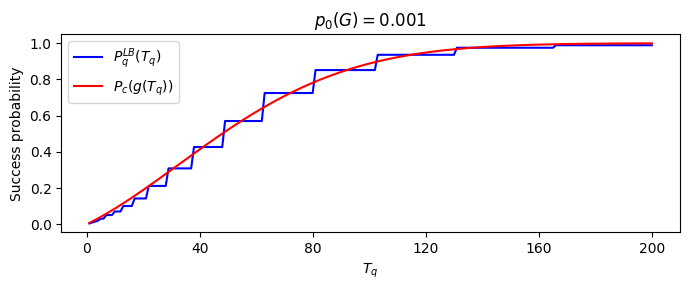

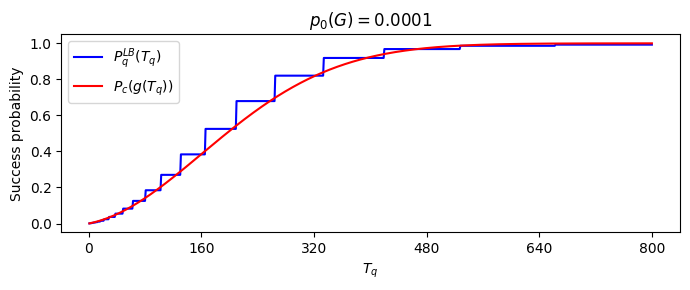

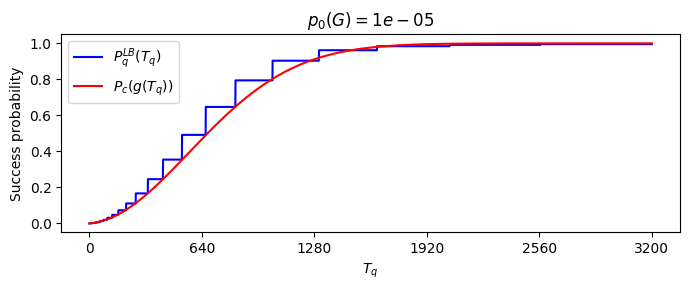

In [ ]:
p_good_base = 0.001
L = 5/4
T_q_base = np.arange(1, 101, dtype=int)
P_lower_base = [lower_bound_success_probability(p_good_base, t, L) for t in T_q_base]

Q = np.clip(np.array(P_lower_base), 0.0, 1.0 - 1e-12)
T_classical_max = np.log(1.0 - Q) / np.log(1.0 - p_good_base)

X = np.column_stack([T_q_base**2, T_q_base])
coeffs, _, _, _ = np.linalg.lstsq(X, T_classical_max, rcond=None)
a, b = coeffs

print(f"f(x) = {a:.2g} x^2 + {b:.2g} x")
print(f"Fitted at p_good={p_good_base}")

p_good_list = [1e-3, 1e-4, 1e-5]
target = 0.98
max_iters = 8

from pathlib import Path
images_dir = Path("Images")
images_dir.mkdir(exist_ok=True)

for pg in p_good_list:
    T_q_max = 100
    for _ in range(max_iters):
        T_q = np.arange(1, T_q_max + 1, dtype=int)
        f_vals = a * T_q**2 + b * T_q
        P_lower = [lower_bound_success_probability(pg, t, L) for t in T_q]
        P_classical_poly = [P_success_classical(pg, t) for t in f_vals]
        if min(P_lower[-1], P_classical_poly[-1]) >= target:
            break
        T_q_max *= 2

    plt.figure(figsize=(7, 3))
    plt.plot(T_q, P_lower, color="blue", label=r"$P_q^{LB}(T_q)$")
    plt.plot(T_q, P_classical_poly, color="red", label=r"$P_c(g(T_q))$")
    plt.title(rf"$p_0(G)={pg}$")
    plt.xlabel(r"$T_q$")
    plt.ylabel("Success probability")
    plt.xticks(np.linspace(0, T_q_max, 6, dtype=int))
    plt.legend()
    plt.tight_layout()
    pdf_name = images_dir / f"p0G_{pg:.0e}.pdf"
    #plt.savefig(pdf_name, format="pdf")
    plt.show()